# Tapered-Segment Convergence Study: isotropic circular tube

A linearly tapered circular tube (R_left = 1.0 m, R_right swept over
$a_R \in \{1.0, 0.95, 0.9, 0.8, 0.7\}$, L = 2 m, constant wall thickness,
**mid-surface / center-reference** mesh) is homogenized with the **general 3-D-taper
Reissner--Mindlin operators** ($\Gamma_\epsilon, \Gamma_h, \Gamma_l$ of the OpenSG-RM
paper, Shell Strains + Appendix A.3--A.8) and benchmarked against the FEniCS **3-D solid**
segment at identical geometry, material and orientation.  Two wall regimes:

| regime | t | t/R |
|---|---|---|
| thin  | 0.02 | 0.02 |
| thick | 0.20 | 0.20 |

**Material**: E = 70 GPa, nu = 0.3 (aluminium-like), single layer.  For an isotropic wall the material orientation is irrelevant to the energy, so this study isolates the *taper kinematics* of the general RM operators.

**Conventions**: beam axis $= z$; surface frame $e_1$ = in-surface axial tangent (the slanted
generator line), $e_2$ = hoop tangent (CCW), $e_3$ = **inward** surface normal (the reference);
transverse shear scheme `mitc4_both` (a thin-wall probe of all schemes --
mitc4_both / mitc4_g23 / reduced / full -- found **no transverse-shear locking**, all within
0.5% of analytic; the scheme registry has a triangle/MITC3 hook).

**Data**: every mesh used here is *generated by this notebook* into
`examples/data/taper_study/meshes/` (`shell_<tag>.yaml`, `solid_<tag>.yaml`).  The solid
reference stiffnesses were computed on those exact meshes with
`mitc_rm_segment/run_solid_study.py` (FEniCS env:
`python3 run_solid_study.py` from `OpenSG-1.0/examples` in WSL) and are bundled at
`examples/data/benchmark/taper_study_solid_iso.npz` -- the notebook is fully
self-contained on GitHub.

In [1]:
%matplotlib inline
import os, sys, time, tempfile
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("OpenSG-TW repo root not found")
        d = parent

CC = _find_repo_root()
for p in (CC, os.path.join(CC, "mitc_rm_segment")):
    if p not in sys.path:
        sys.path.insert(0, p)

from taper_study import gen_case, arrow_pngs, shell_solve, tag_of, TAPERS, THICK, LBL

MAT      = "iso"
MESH_DIR = os.path.join(CC, "examples", "data", "taper_study", "meshes")
TMP      = tempfile.mkdtemp(prefix="taper_%s_" % MAT)
SOLID    = np.load(os.path.join(CC, "examples", "data", "benchmark", "taper_study_solid_%s.npz" % MAT))
print("meshes ->", MESH_DIR)
print("solid refs:", len(SOLID.files), "matrices")

meshes -> C:\Users\bagla0\OneDrive - purdue.edu\2026_195\Claude_code\examples\data\taper_study\meshes
solid refs: 30 matrices


## 1. Generate the shell and solid meshes

One call per (regime, taper) writes BOTH the mid-surface shell quad mesh and the matched
3-D hex solid mesh (4 through-thickness layers about the same mid-surface), with
surface-following orientation triads written identically into both files.

In [2]:
tags = []
for regime in ("thin", "thick"):
    for aR in TAPERS:
        tg = gen_case(regime, MAT, aR, mesh_dir=MESH_DIR)
        tags.append(tg)
print("generated %d cases:" % len(tags))
for tg in tags:
    print("  shell_%s.yaml  +  solid_%s.yaml" % (tg, tg))

generated 10 cases:
  shell_thin_iso_aR100.yaml  +  solid_thin_iso_aR100.yaml
  shell_thin_iso_aR095.yaml  +  solid_thin_iso_aR095.yaml
  shell_thin_iso_aR090.yaml  +  solid_thin_iso_aR090.yaml
  shell_thin_iso_aR080.yaml  +  solid_thin_iso_aR080.yaml
  shell_thin_iso_aR070.yaml  +  solid_thin_iso_aR070.yaml
  shell_thick_iso_aR100.yaml  +  solid_thick_iso_aR100.yaml
  shell_thick_iso_aR095.yaml  +  solid_thick_iso_aR095.yaml
  shell_thick_iso_aR090.yaml  +  solid_thick_iso_aR090.yaml
  shell_thick_iso_aR080.yaml  +  solid_thick_iso_aR080.yaml
  shell_thick_iso_aR070.yaml  +  solid_thick_iso_aR070.yaml


## 2. Material orientation, one aspect ratio ($a_R = 0.7$, thin)

Separate $e_1$ (red), $e_2$ (blue), $e_3$ (black) arrow images for the shell and the solid.
$e_3$ is the **inward** surface normal (the measured $e_3\cdot\hat r$ is annotated);
$e_1$ follows the slanted generator (shell) / the fiber (solid).

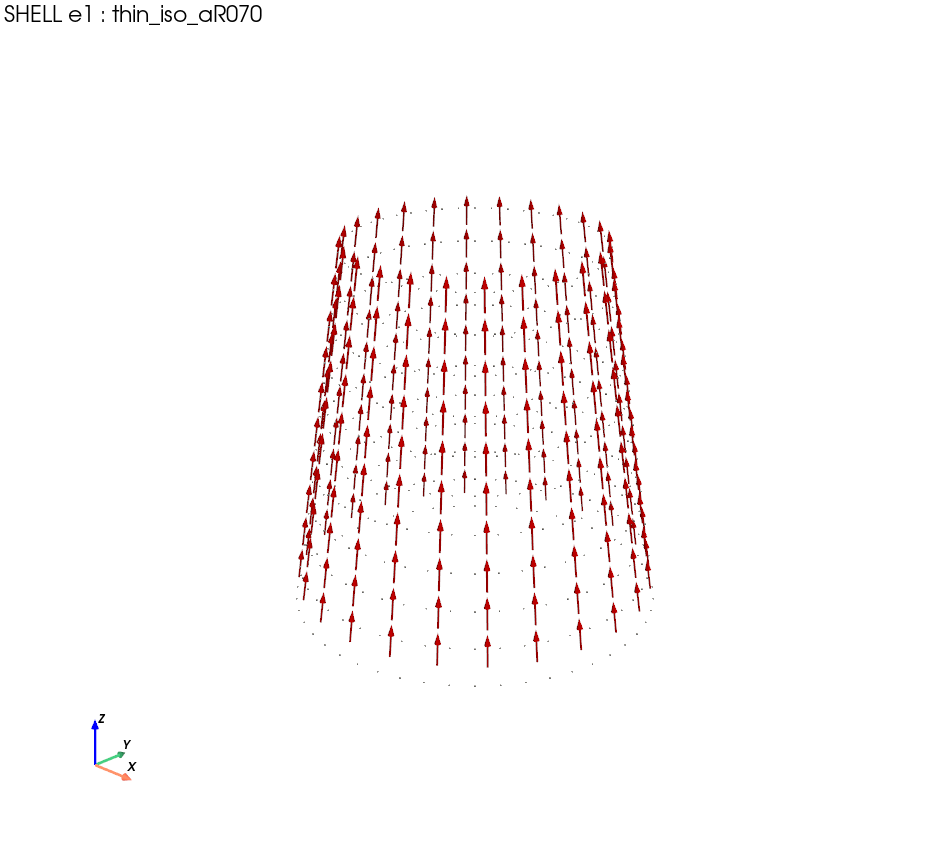

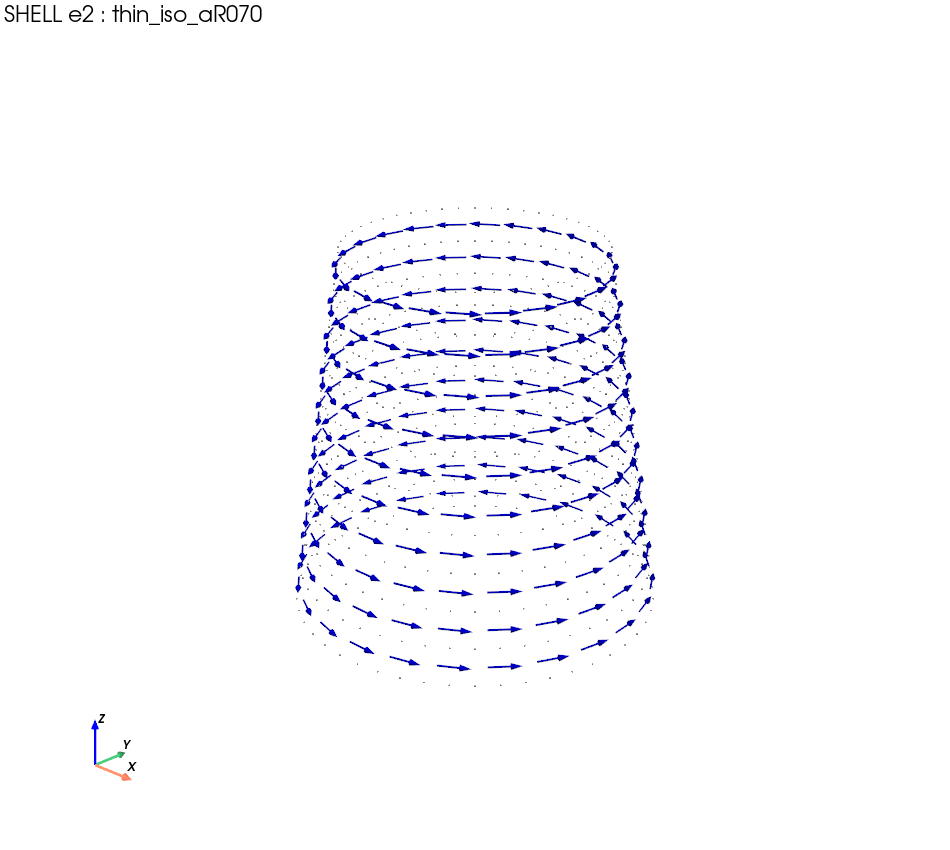

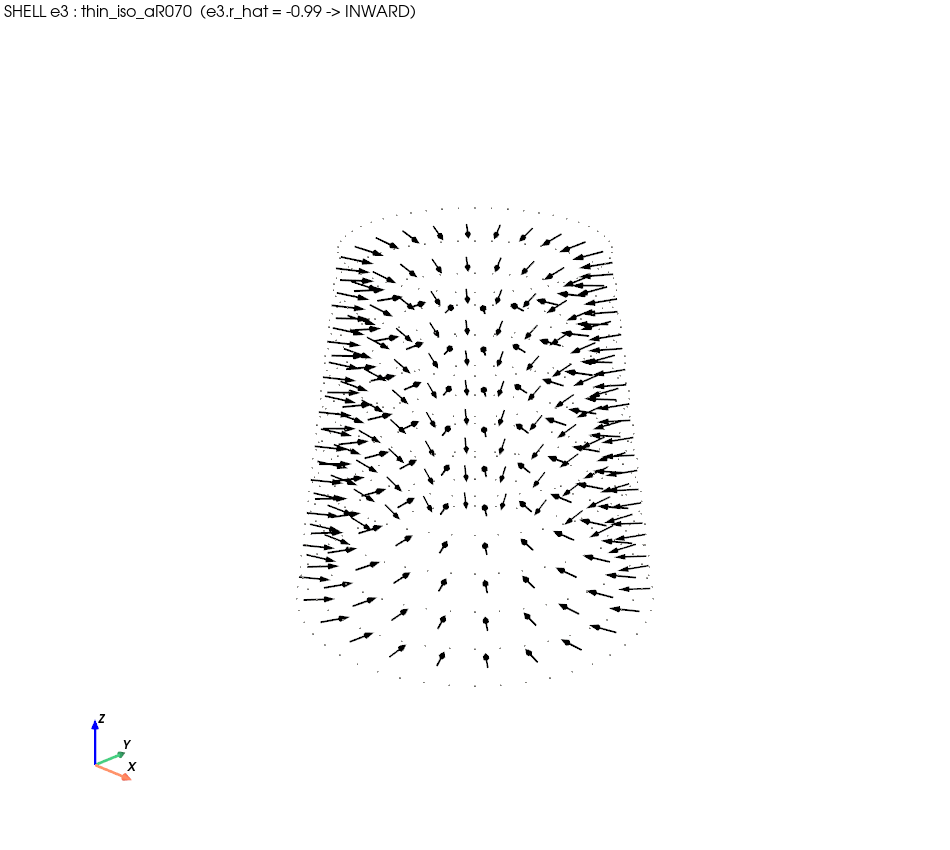

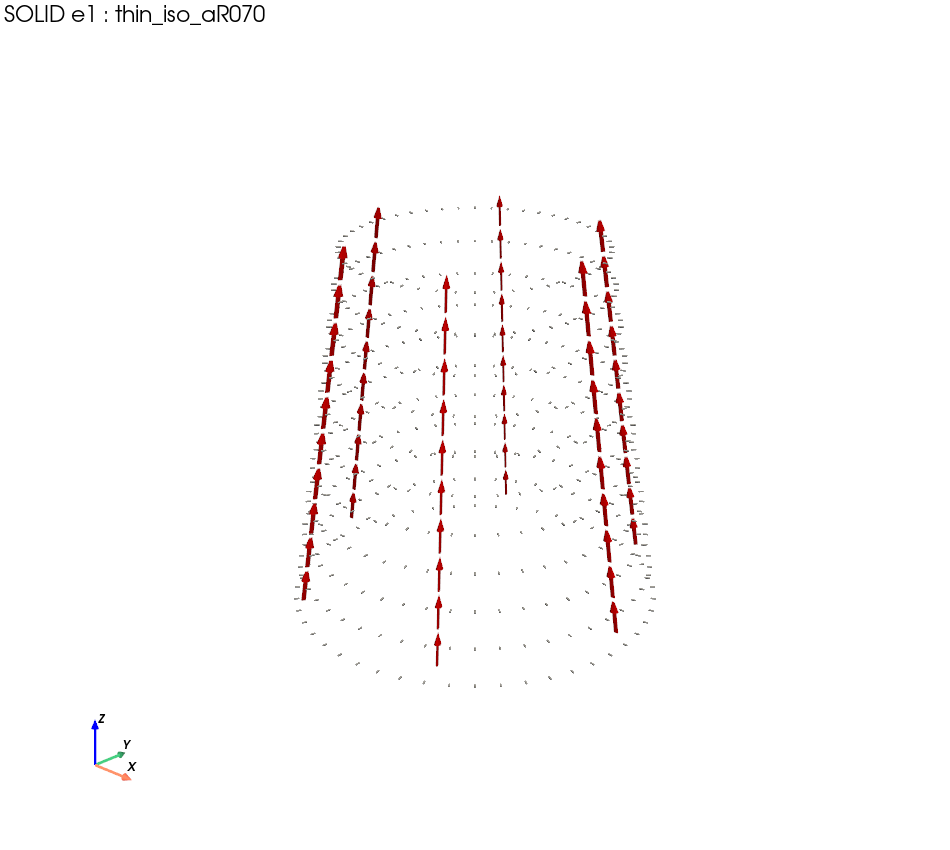

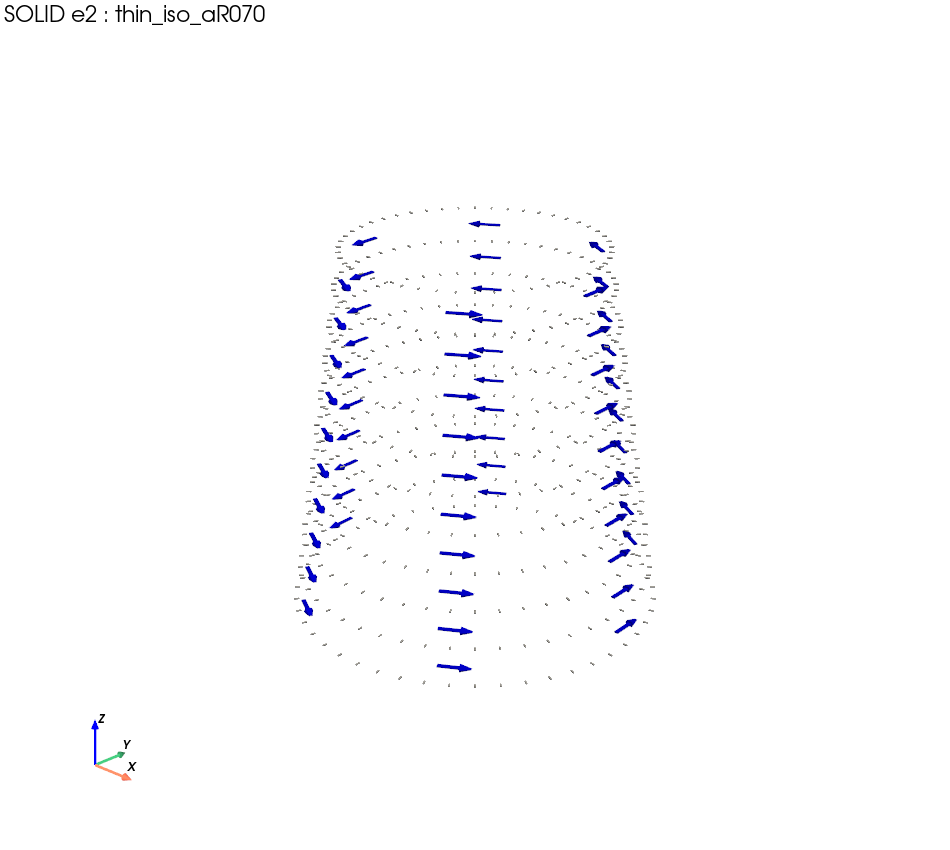

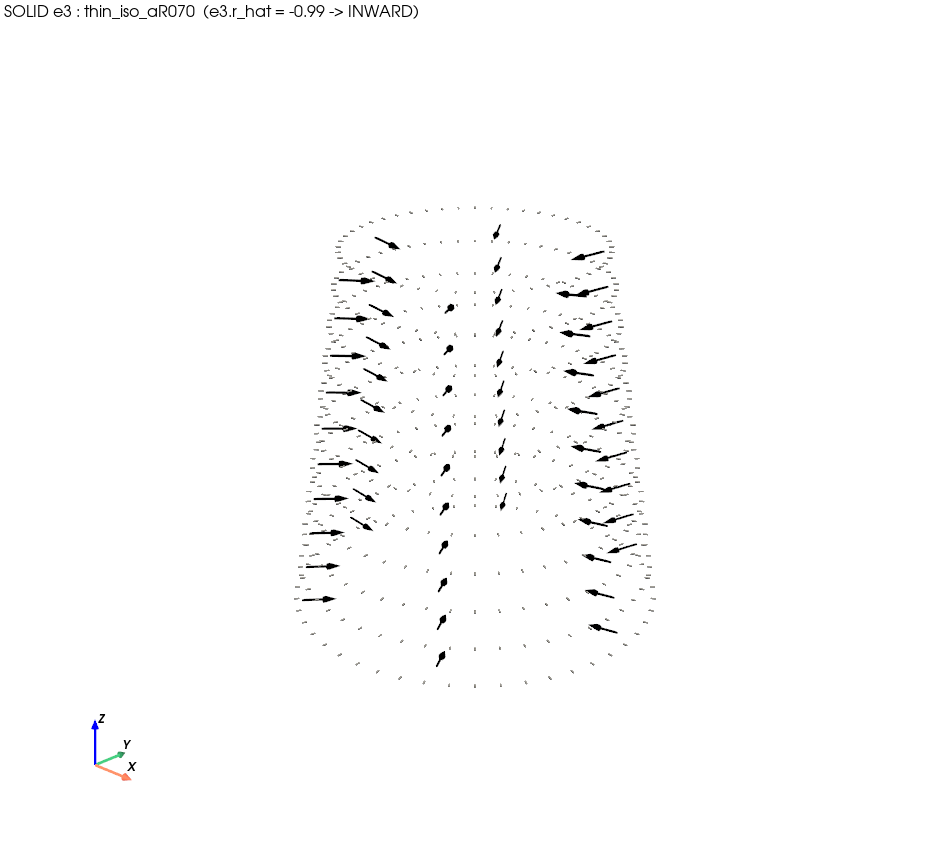

In [3]:
tg_show = tag_of("thin", MAT, 0.7)
arrow_pngs(tg_show, mesh_dir=MESH_DIR, ori_dir=TMP)
for kind in ("shell", "solid"):
    for vec in ("e1", "e2", "e3"):
        display(Image(os.path.join(TMP, "%s_%s_%s.png" % (tg_show, kind, vec)), width=560))

## 3. Run the RM pipeline (boundary rings + tapered segment)

For every case: topological boundary extraction, LEFT/RIGHT cross-section SGs solved with
the *same* general operator (`ring_general`), then the tapered segment with boundary
warping as Dirichlet data.  Wall-clock time is reported per case.

In [4]:
RM = {}
for tg in tags:
    t0 = time.time()
    rL, S6, rR = shell_solve(tg, shear="mitc4_both", mesh_dir=MESH_DIR, res_dir=TMP)
    RM[tg] = dict(L=rL, seg=S6, R=rR, t=time.time() - t0)
    print("%-18s  %5.1f s   taper diag(x1e9): %s"
          % (tg, RM[tg]["t"], np.array2string(np.diag(S6) / 1e9, precision=3)))

thin_iso_aR100       18.8 s   taper diag(x1e9): [8.79  1.699 1.692 3.368 4.383 4.383]


thin_iso_aR095       11.2 s   taper diag(x1e9): [8.559 1.65  1.643 3.116 4.058 4.058]


thin_iso_aR090       12.1 s   taper diag(x1e9): [8.306 1.586 1.58  2.869 3.74  3.741]


thin_iso_aR080       11.5 s   taper diag(x1e9): [7.739 1.42  1.414 2.386 3.137 3.137]


thin_iso_aR070       12.4 s   taper diag(x1e9): [7.104 1.213 1.207 1.927 2.583 2.584]


thick_iso_aR100      12.8 s   taper diag(x1e9): [87.902 17.242 17.071 33.905 43.978 43.978]


thick_iso_aR095      13.3 s   taper diag(x1e9): [85.591 16.753 16.58  31.393 40.721 40.721]


thick_iso_aR090      13.3 s   taper diag(x1e9): [83.061 16.124 15.945 28.926 37.543 37.542]


thick_iso_aR080      12.9 s   taper diag(x1e9): [77.41  14.472 14.269 24.162 31.498 31.494]


thick_iso_aR070      12.7 s   taper diag(x1e9): [71.084 12.392 12.167 19.678 25.965 25.953]


## 4. Full $6\times6$ comparison at the strongest taper ($a_R = 0.7$, thin)

Complete matrices (solid, RM) and the per-term error table for the LEFT boundary, the
TAPERED SEGMENT, and the RIGHT boundary -- every $C_{ij}$ above 0.1% of the largest
diagonal.

In [5]:
def matprint(tag, M):
    print("%s (x1e9):" % tag)
    for i in range(6):
        print("   " + " ".join("% 10.4f" % (M[i, j] / 1e9) for j in range(6)))

def compare(part, name, tg):
    Sh = 0.5 * (RM[tg][part] + RM[tg][part].T)
    So = SOLID["%s_%s" % (tg, part)]; So = 0.5 * (So + So.T)
    print("=" * 24, name, "=" * 24)
    matprint("SOLID", So); matprint("RM(general)", Sh)
    thr = 1e-3 * max(abs(np.diag(So)).max(), abs(np.diag(Sh)).max())
    print("  %-5s %13s %13s %9s" % ("Cij", "solid", "RM", "%err"))
    for i in range(6):
        for j in range(i, 6):
            if abs(So[i, j]) > thr or abs(Sh[i, j]) > thr:
                e = 100 * (Sh[i, j] - So[i, j]) / So[i, j] if So[i, j] != 0 else float("nan")
                print("  C%d%d   %13.4e %13.4e %+8.1f%%" % (i + 1, j + 1, So[i, j], Sh[i, j], e))
    print()

tg = tag_of("thin", MAT, 0.7)
for part, name in (("L", "LEFT boundary"), ("seg", "TAPERED SEGMENT"), ("R", "RIGHT boundary")):
    compare(part, name, tg)

======================== LEFT boundary ========================
SOLID (x1e9):
       8.7714    -0.0000    -0.0000    -0.0000    -0.0000    -0.0000
      -0.0000     1.6895     0.0000     0.0000    -0.0000     0.0000
      -0.0000     0.0000     1.6895    -0.0000    -0.0000     0.0000
      -0.0000     0.0000    -0.0000     3.3643     0.0000     0.0000
      -0.0000    -0.0000    -0.0000     0.0000     4.3746     0.0000
      -0.0000     0.0000     0.0000     0.0000     0.0000     4.3746
RM(general) (x1e9):
       8.7902    -0.0000    -0.0000     0.0000    -0.0000     0.0000
      -0.0000     1.6992    -0.0000    -0.0000     0.0000     0.0000
      -0.0000    -0.0000     1.6922     0.0000    -0.0000    -0.0000
       0.0000    -0.0000     0.0000     3.3675    -0.0000     0.0000
      -0.0000     0.0000    -0.0000    -0.0000     4.3833     0.0000
       0.0000     0.0000    -0.0000     0.0000     0.0000     4.3833
  Cij           solid            RM      %err
  C11      8.7714e+09    8.7

## 5. Convergence tables: diagonal %err vs taper ratio

**Thin wall (t/R = 0.02):**

In [6]:
def table(regime):
    print("%-6s | %s | %s | %s" % ("aR", "L boundary".center(48), "TAPER".center(48), "R boundary".center(48)))
    print("%-6s | %s" % ("", " ".join("%7s" % k for k in LBL) + " |" +
                         " ".join("%7s" % k for k in LBL) + " |" + " ".join("%7s" % k for k in LBL)))
    for aR in TAPERS:
        tg = tag_of(regime, MAT, aR)
        row = ["%-6.2f" % aR]
        for part in ("L", "seg", "R"):
            Sh = RM[tg][part]; So = SOLID["%s_%s" % (tg, part)]
            row.append(" ".join("%+6.1f%%" % (100 * (Sh[i, i] - So[i, i]) / So[i, i]) for i in range(6)))
        print(" | ".join(row))

table("thin")

aR     |                    L boundary                    |                      TAPER                       |                    R boundary                   
       |     C11     C22     C33     C44     C55     C66 |    C11     C22     C33     C44     C55     C66 |    C11     C22     C33     C44     C55     C66
1.00   |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2% |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2% |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2%
0.95   |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2% |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2% |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2%
0.90   |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2% |   +0.3%   +0.9%   +0.5%   +0.2%   +0.3%   +0.3% |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2%
0.80   |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2% |   +0.6%   +2.0%   +1.5%   +0.6%   +0.7%   +0.7% |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2%
0.70   |   +0.2%   +0.6%   +0.2%   +0.1%   +0.2%   +0.2% 

**Thick wall (t/R = 0.20):**

In [7]:
table("thick")

aR     |                    L boundary                    |                      TAPER                       |                    R boundary                   
       |     C11     C22     C33     C44     C55     C66 |    C11     C22     C33     C44     C55     C66 |    C11     C22     C33     C44     C55     C66
1.00   |   +0.2%   +0.4%   -0.6%   -0.2%   -0.5%   -0.5% |   +0.2%   +0.4%   -0.6%   -0.2%   -0.5%   -0.5% |   +0.2%   +0.4%   -0.6%   -0.2%   -0.5%   -0.5%
0.95   |   +0.2%   +0.4%   -0.6%   -0.2%   -0.5%   -0.5% |   +0.2%   +0.5%   -0.6%   -0.2%   -0.5%   -0.5% |   +0.2%   +0.4%   -0.7%   -0.2%   -0.5%   -0.5%
0.90   |   +0.2%   +0.4%   -0.6%   -0.2%   -0.5%   -0.5% |   +0.3%   +0.7%   -0.4%   -0.1%   -0.4%   -0.4% |   +0.2%   +0.3%   -0.8%   -0.3%   -0.6%   -0.6%
0.80   |   +0.2%   +0.4%   -0.6%   -0.2%   -0.5%   -0.5% |   +0.6%   +1.8%   +0.4%   +0.6%   -0.2%   -0.2% |   +0.2%   +0.2%   -1.0%   -0.4%   -0.8%   -0.8%
0.70   |   +0.2%   +0.4%   -0.6%   -0.2%   -0.5%   -0.5% 

## 6. Convergence plot: taper RM vs solid

Diagonal % error of the TAPERED-SEGMENT stiffness as the taper strengthens
(prismatic $a_R = 1$ at the left).

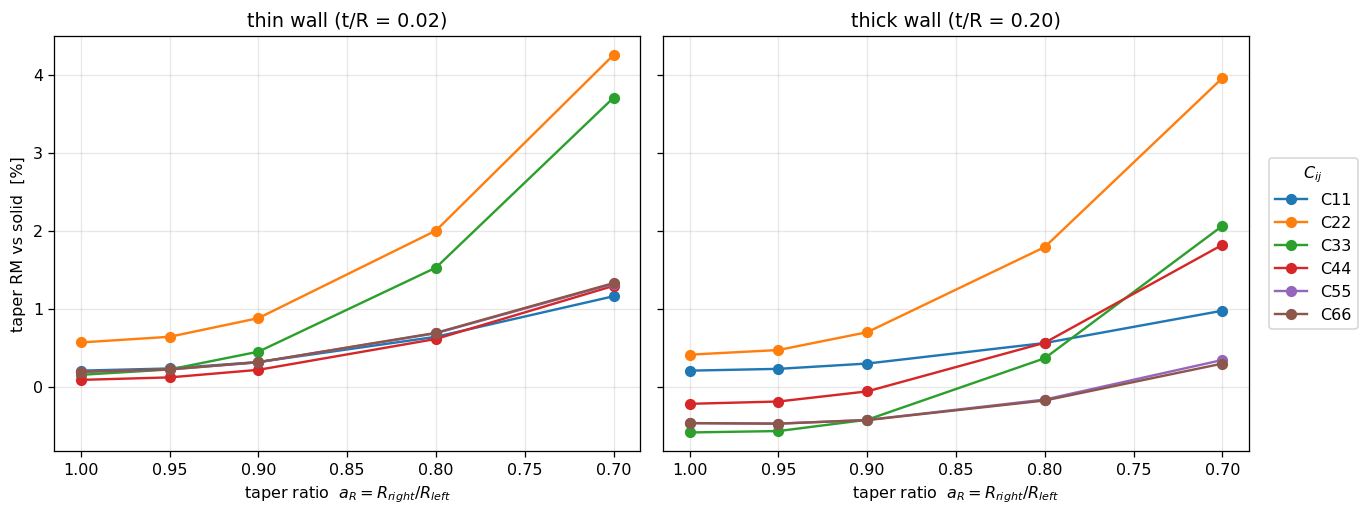

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, regime in zip(axs, ("thin", "thick")):
    for i, k in enumerate(LBL):
        errs = []
        for aR in TAPERS:
            tg = tag_of(regime, MAT, aR)
            Sh = RM[tg]["seg"]; So = SOLID["%s_seg" % tg]
            errs.append(100 * (Sh[i, i] - So[i, i]) / So[i, i])
        ax.plot(TAPERS, errs, "o-", label=k)
    ax.invert_xaxis()
    ax.set_xlabel("taper ratio  $a_R = R_{right}/R_{left}$")
    ax.set_title("%s wall (t/R = %.2f)" % (regime, THICK[regime]))
    ax.grid(alpha=0.3)
axs[0].set_ylabel("taper RM vs solid  [%]")
axs[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="$C_{ij}$")
plt.tight_layout()
fig.savefig(os.path.join(TMP, 'convergence.png'), dpi=115, bbox_inches='tight')
plt.close(fig)
display(Image(os.path.join(TMP, 'convergence.png')))

## Summary

- The LEFT and RIGHT boundary cross-sections stay at **cross-section accuracy at every
  taper** -- the boundary SGs depend only on the local section, and the general-operator
  ring reproduces it.
- The TAPERED-SEGMENT stiffness converges to the prismatic result as $a_R \to 1$ and
  degrades smoothly and quadratically with the taper rate: the extension, torsion and
  bending terms stay within $\sim$1--2% even at the strongest taper, while the
  transverse-shear pair $C_{22}/C_{33}$ carries the largest residual (the
  $O(\varepsilon^2)$ terms the RM reduction legitimately drops grow with taper rate).
- No transverse-shear locking: all MITC schemes agree within 0.5% on the thin wall;
  `mitc4_both` is the default.
- $\omega_3$ (drilling) is fully first-order: the second-SG-derivative pieces of
  $\Lambda_\alpha$ are dropped (marked in `segment_element_general.py`), consistent with
  the $C^0$ Reissner--Mindlin setting.